# **📊 Proyecto TelecomX - Parte 2**
---

<br>

**Challenge**: Segunda parte del desafío Telecom X de Data Science de [Alura Latam](https://www.aluracursos.com/)

**Formación**: Estadisticas y Machine Learning G9 - ONE

**Alumna**: Aiello Mariana

<br>




## 🎯 Objetivo del Proyecto (Parte 2):

Desarrollar y evaluar modelos predictivos de *Machine Learning* capaces de **anticipar la evasión de clientes (churn)** en la empresa TelecomX. Para ello, se utilizarán algoritmos de clasificación supervisada, como **Regresión Logística** y **Random Forest**, con el fin de identificar patrones que permitan detectar clientes con alto riesgo de cancelar el servicio.

El análisis se realizará a partir del dataset limpio y estandarizado obtenido en la **Parte 1** del proyecto de Telecom, donde se aplicaron procesos de tratamiento de valores nulos, estandarización de variables y creación de métricas de negocio.

(con cierto proceso de limpieza y estandarizacion realizado en ...) !!



El proyecto se estructura en cuatro fases principales:

### 1. Preparación de datos
- Encoding de variables
- Normalización
- Balanceo de clases

### 2. División del dataset
Separación de datos de entrenamiento y prueba mediante **train-test split estratificado**.

### 3. Modelado predictivo
Entrenamiento de modelos de clasificación.

### 4. Evaluación y análisis
Comparación de métricas de desempeño para seleccionar el modelo más efectivo y generar conclusiones orientadas a estrategias de retención de clientes.

<br>


## 📂 <font color=lightblue> 1. Preparación de los Datos </font>

Antes de entrenar los modelos predictivos, es necesario transformar el dataset limpio obtenido en la **Parte 1** en un formato adecuado para los algoritmos de Machine Learning.  Los modelos no pueden procesar directamente variables de texto o categorías, por lo que es necesario convertir toda la información en representaciones numéricas.

En esta etapa se realizan diferentes procesos de **preprocesamiento de datos**, incluyendo la selección de variables relevantes, la codificación de variables categóricas, el análisis del balanceo de la variable objetivo y la normalización de variables numéricas.

<br>

El proceso incluye las siguientes tareas:

1. **Extracción del dataset** tratado.
2. **Eliminación de columnas irrelevantes** o que no aportan valor predictivo.
3. **Encoding de variables categóricas** para convertirlas en representaciones numéricas.
4. **Verificación del balanceo de clases** de la variable objetivo (churn).
5. **Escalado de variables numéricas** para mejorar el rendimiento de algunos algoritmos.

<br>

**Dataset de entrada:** `datos_tratados.csv`  
**Dimensiones:** 7.043 registros × 23 variables

### 1.1 Extracción del Dataset Tratado

En esta etapa se importa el archivo `datos_tratados.csv`, generado al final del **Análisis Exploratorio de Datos (EDA)** de la Parte 1 del proyecto de Telecom.

Este dataset contiene la información ya **limpia y estandarizada**, incluyendo transformaciones básicas aplicadas durante el proceso de preparación inicial, como:
- conversión de variables binarias a valores numéricos (0/1)
- estandarización de nombres de columnas y categorías     !!!xxxxx!!!!
- creación de algunas variables derivadas relevantes para el análisis

Además, se importan las librerías necesarias que serán utilizadas durante la fase de **preprocesamiento y modelado**.

In [2]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# librerías para ML y preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE

# dataset con datos tratados de Telecom - parte 1
df = pd.read_csv('datos_tratados.csv')

# mostrar DataFrame
print(f"\nDataset cargado exitosamente")
print(f"   • Registros: {df.shape[0]:,}")
print(f"   • Variables: {df.shape[1]}\n")

print(f"\nIformación general:\n")
print(df.info())

print(f"\nPrimeros registros:\n")
df.head(4)


Dataset cargado exitosamente
   • Registros: 7,043
   • Variables: 23


Iformación general:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         7043 non-null   object 
 1   churn               7043 non-null   int64  
 2   gender              7043 non-null   int64  
 3   senior_citizen      7043 non-null   int64  
 4   partner             7043 non-null   int64  
 5   dependents          7043 non-null   int64  
 6   tenure              7043 non-null   int64  
 7   phone_service       7043 non-null   int64  
 8   multiple_lines      7043 non-null   object 
 9   internet_service    7043 non-null   object 
 10  online_security     7043 non-null   object 
 11  online_backup       7043 non-null   object 
 12  device_protection   7043 non-null   object 
 13  tech_support        7043 non-null   object 
 14  streaming_

,customer_id,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,cuentas_diarias,cantidad_servicios
0,0002-ORFBO,0,1,0,1,1,9,1,No,DSL,...,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19,3
1,0003-MKNFE,0,0,0,0,0,9,1,Yes,DSL,...,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00,1
2,0004-TLHLJ,1,0,0,0,0,4,1,No,Fiber optic,...,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46,1
3,0011-IGKFF,1,0,1,1,0,13,1,No,Fiber optic,...,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27,4


### 1.2 Eliminación de Columnas Irrelevantes

El rendimiento de un modelo predictivo puede verse afectado si se incluyen variables redundantes o sin relación con la variable objetivo (*churn*). A partir de los resultados obtenidos durante el **Análisis Exploratorio(EDA)** (Parte 1) se decide eliminar las siguientes columnas:


* **`customer_id`:** identificador único del sistema sin poder predictivo.
* **`cuentas_diarias`:** variable redundante. Al ser una división matemática directa del cargo mensual (`monthly_charges` / 30), aporta exactamente la misma información.
* **`total_charges`:** presenta multicolinealidad. Tiene una correlación altísima con la antigüedad (`tenure`). Mantener ambas variables explicaría lo mismo dos veces, confundiendo a los algoritmos.
* **`gender`:** el análisis visual demostró que la proporción de abandono es equitativa para hombres y mujeres, por lo que el género no influye en la cancelación.

#### Verificación de Independencia Estadística (Chi-Cuadrado)

Se aplica la **Prueba de Chi-Cuadrado** Para corroborar si existen otras columnas categóricas o binarias que no aportan valor al modelo.

Si el **valor p (p-value)** es mayor a 0.05, se concluye que la variable es independiente y no influye en la decisión de cancelación del cliente. En ese caso, la columna puede ser eliminada.

In [3]:
print("PRUEBA DE CHI-CUADRADO\n")
from scipy.stats import chi2_contingency

# columnas que no entran en la prueba
columnas_excluidas = ['customer_id', 'churn', 'tenure', 'monthly_charges', 'total_charges', 'cuentas_diarias', 'cantidad_servicios']

# filtrar para obtener variables a evaluar
variables_a_evaluar = [col for col in df.columns if col not in columnas_excluidas]

# listas para guardar los resultados
variables_utiles = []
variables_a_descartar = []

# bucle para probar todas las variables
for col in variables_a_evaluar:
    tabla_contingencia = pd.crosstab(df[col], df['churn'])
    chi2, p_value, dof, expected = chi2_contingency(tabla_contingencia)

    if p_value > 0.05:
        variables_a_descartar.append(col)
        print(f"x {col}:  p-value = {p_value:.4f} ---> Sin relación (Eliminar)")
    else:
        variables_utiles.append(col)
        print(f"• {col}:  p-value = {p_value:.4f} -> Fuerte relación (Conservar)")

print(f"\nResumen: se sugiere eliminar {len(variables_a_descartar)} variables: {variables_a_descartar}")

PRUEBA DE CHI-CUADRADO

x gender:  p-value = 0.4866 ---> Sin relación (Eliminar)
• senior_citizen:  p-value = 0.0000 -> Fuerte relación (Conservar)
• partner:  p-value = 0.0000 -> Fuerte relación (Conservar)
• dependents:  p-value = 0.0000 -> Fuerte relación (Conservar)
x phone_service:  p-value = 0.3388 ---> Sin relación (Eliminar)
• multiple_lines:  p-value = 0.0035 -> Fuerte relación (Conservar)
• internet_service:  p-value = 0.0000 -> Fuerte relación (Conservar)
• online_security:  p-value = 0.0000 -> Fuerte relación (Conservar)
• online_backup:  p-value = 0.0000 -> Fuerte relación (Conservar)
• device_protection:  p-value = 0.0000 -> Fuerte relación (Conservar)
• tech_support:  p-value = 0.0000 -> Fuerte relación (Conservar)
• streaming_tv:  p-value = 0.0000 -> Fuerte relación (Conservar)
• streaming_movies:  p-value = 0.0000 -> Fuerte relación (Conservar)
• contract:  p-value = 0.0000 -> Fuerte relación (Conservar)
• paperless_billing:  p-value = 0.0000 -> Fuerte relación (Conser

**Resultados de la prueba de Chi-Cuadrado**

Los resultados indican que las variables **`gender`** y **`phone_service`**
no tienne un impacto significativo en el comportamiento de evasión de los clientes, por lo que pueden ser eliminadas del dataset.


In [4]:
print('Eliminación de columnas irrelevantes\n')

# columnas a eliminar
columnas_a_eliminar = ['customer_id', 'total_charges', 'cuentas_diarias', 'gender', 'phone_service']
print(f"• Columnas a eliminar: {columnas_a_eliminar}\n")

# eliminación de columnas
df= df.drop(columns=columnas_a_eliminar)
print(f"• Columnas restantes: {df.columns}\n")
print(f"Nuevas dimensiones: {df.shape}")





Eliminación de columnas irrelevantes

• Columnas a eliminar: ['customer_id', 'total_charges', 'cuentas_diarias', 'gender', 'phone_service']

• Columnas restantes: Index(['churn', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'paperless_billing', 'payment_method',
       'monthly_charges', 'cantidad_servicios'],
      dtype='object')

Nuevas dimensiones: (7043, 18)


### 1.3 Encoding: Transformación de Variables Categóricas

Los algoritmos de Machine Learning requieren que todos los datos de entrada sean numéricos para poder realizar operaciones matemáticas. Se aplicará la técnica **One-Hot Encoding** (`pd.get_dummies`) y se utilizará el parámetro `drop_first=True` para omitir la primera categoría generada de cada variable.

<br>

**Variables ya procesadas (Telecom parte 1):** <br>
Durante el Análisis Exploratorio estas variables binarias ya fueron convertidas a formato 0 y 1.
*  `partner`, `dependents`, `paperless_billing`:



**Variables a procesar (One-Hot Encoding):** <br>
Las siguientes variables nominales permanecen en formato de texto y serán transformadas creando columnas binarias para cada una de sus categorías:
* `multiple_lines`, `internet_service`, `contract`, `payment_method`
* `online_security`, `online_backup`, `device_protection`, `tech_support`, `streaming_tv`, `streaming_movies` (Servicios adicionales)





In [5]:
print('ENCODING DE VARIABLES CATEGÓRICAS\n')

# Identificamos las columnas categóricas restantes (tipo object)
columnas_categoricas = df.select_dtypes(include=['object']).columns
print(f"Columnas a codificar con One-Hot Encoding:\n {columnas_categoricas}\n")

# aplicamos One-Hot encoding
df_encoded = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True, dtype=int)

# mostrar resultados
print("Transformación completada.")
print(f"Dimensiones originales: {df.shape}")
print(f"Dimensiones post-encoding: {df_encoded.shape}")
print(f"Total de nuevas columnas generadas: {df_encoded.shape[1] - df.shape[1]}\n")
df_encoded.sample(3)

ENCODING DE VARIABLES CATEGÓRICAS

Columnas a codificar con One-Hot Encoding:
 Index(['multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'payment_method'],
      dtype='object')

Transformación completada.
Dimensiones originales: (7043, 18)
Dimensiones post-encoding: (7043, 29)
Total de nuevas columnas generadas: 11



,churn,senior_citizen,partner,dependents,tenure,paperless_billing,monthly_charges,cantidad_servicios,multiple_lines_No phone service,multiple_lines_Yes,...,tech_support_Yes,streaming_tv_No internet service,streaming_tv_Yes,streaming_movies_No internet service,streaming_movies_Yes,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
1866,0,0,0,0,10,1,51.65,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2832,0,0,1,0,72,1,94.25,4,0,1,...,1,0,0,0,0,0,1,0,0,0
6378,1,0,0,0,39,1,48.95,4,1,0,...,1,0,1,0,0,0,0,1,0,0


### 1.4 Verificación de la Proporción de Cancelación (Churn)

Se analiza la distribución de la variable objetivo (`churn`) para detectar posibles desbalanceos que puedan afectar el rendimiento de los modelos predictivos.

* **Desbalanceo de clases:** ocurre cuando una clase está significativamente más representada que la otra. Esto puede sesgar los resultados, provocando que los modelos predigan con mayor frecuencia a la clase mayoritaria.
* **Impacto técnico:** así se genera una **exactitud (accuracy)** aparentemente alta, que oculta la incapacidad del algoritmo para identificar los casos minoritarios.

PROPORCIÓN DE CANCELACIÓN




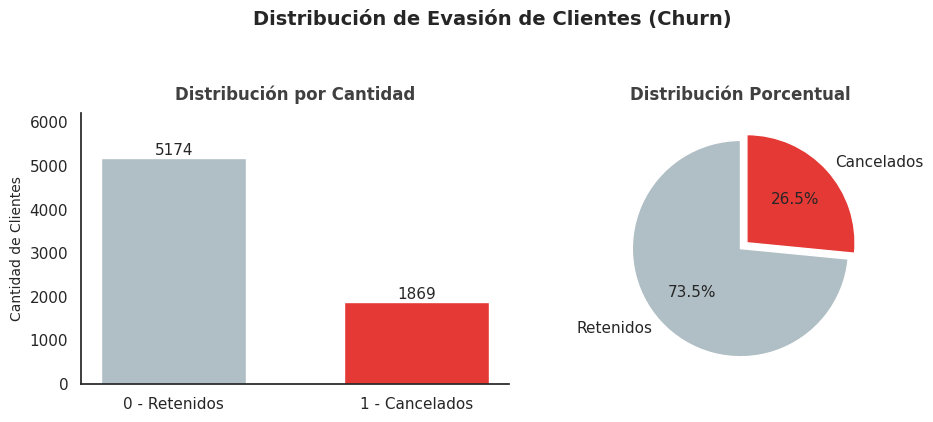


VERIFICACIÓN DE DESBALANCEO



,Estado,Cantidad,Porcentaje (%)
0,0 - Retenidos,5174,73.46
1,1 - Cancelados,1869,26.54



Ratio de desbalanceo: 2.77 a 1


In [6]:
print('PROPORCIÓN DE CANCELACIÓN\n\n')

# Cálculo de proporciones y ratio de desbalanceo
conteo = df_encoded['churn'].value_counts()
proporcion = df_encoded['churn'].value_counts(normalize=True) * 100
ratio = conteo[0] / conteo[1]

# Estética (gris retención - rojo evasión)
colores_alerta = ['#B0BEC5', '#E53935']
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Distribución de Evasión de Clientes (Churn)', fontsize=14, fontweight='bold', y=1.05)

# Grafico de Barras (cantidades)
axes[0].bar(['0 - Retenidos', '1 - Cancelados'], conteo.values, color=colores_alerta, width=0.6)
axes[0].set_title('Distribución por Cantidad', fontsize=12, pad=10, fontweight='bold', color='#404040')
axes[0].set_ylabel('Cantidad de Clientes', fontsize=10)
axes[0].set_ylim(0, conteo.max() * 1.20)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 80, str(v), ha='center', fontsize=11)

# Gráfico de Torta (porcentaje)
axes[1].pie(conteo.values, labels=['Retenidos', 'Cancelados'],
            autopct='%1.1f%%', colors=colores_alerta, startangle=90,
            explode=(0, 0.08), textprops={'fontsize': 11})
axes[1].set_title('Distribución Porcentual', fontsize=12, pad=10, fontweight='bold', color='#404040')

plt.tight_layout()
plt.show()


# RESUMEN
print("\nVERIFICACIÓN DE DESBALANCEO\n")
resumen = pd.DataFrame({
    'Estado': ['0 - Retenidos', '1 - Cancelados'],
    'Cantidad': conteo.values,
    'Porcentaje (%)': proporcion.values.round(2)
})
display(resumen)

print(f"\nRatio de desbalanceo: {ratio:.2f} a 1")

**Interpretación de los resultados:**

Se identifica un **desbalanceo moderado** en el dataset, con un ratio aproximado de **2.7 a 1**. Esto indica que por cada cliente que cancela el servicio (clase minoritaria), existen casi tres clientes que permanecen activos (**clase mayoritaria - Retención**).

* **Observación:** la mayor proporción de clientes en la clase de Retención podría sesgar las métricas de desempeño si no se trata adecuadamente.
* **Decisión:** se aplicará la técnica de balanceo **SMOTE** en la siguiente etapa para equilibrar las clases y mejorar la capacidad del modelo para detectar la clase minoritaria (evasión).

### 1.5 Balanceo de clases

Se identifica la necesidad de aplicar técnicas de balanceo para mejorar la capacidad predictiva del modelo de detectar a la clase minoritaria (Evasión).

Para evitar la fuga de datos (Data Leakage), se aplicará la **técnica SMOTE** luego de la **separación de los datos en entrenamiento y prueba** (Punto 3.1). De esta manera, el balanceo se realizará exclusivamente sobre el conjunto de entrenamiento, garantizando que el grupo de prueba permanezca con datos reales y no contaminados por registros sintéticos.

### 1.5 Balanceo de clases

Se identifica la necesidad de aplicar técnicas de balanceo para mejorar la capacidad predictiva del modelo de detectar la clase minoritaria (Evasión).

Para evitar la fuga de datos (Data Leakage), se aplicará la **técnica SMOTE** luego de la **separación de los datos en entrenamiento y prueba** (Punto 3.1). De esta manera, el balanceo se realizará exclusivamente sobre el conjunto de entrenamiento, garantizando que el conjunto de prueba permanezca con datos reales y no contaminados por registros sintéticos.

### 1.6 Estandarización de Variables Numéricas

Se evalúa la necesidad de transformar los datos según los algoritmos seleccionados para la etapa de modelado:

* **Regresión Logística:** es un modelo lineal paramétrico, sensible a la magnitud de las variables. El proceso de **estandarización** le permite evitar que las variables con valores numéricos más altos influyan desproporcionadamente en el cálculo de los coeficientes.

* **Random Forest:** al estar basado en árboles de decisión, no es sensible a la escala de los datos. No obstante, aplicar esta transformación no afecta negativamente su rendimiento.


Para cumplir con este preprocesamiento, se aplica la técnica `StandardScaler` sobre las variables numéricas continuas. Este método utiliza el cálculo de Z-score para centrar la media en 0 y la desviación estándar en 1, manteniendo sin modificación las variables categóricas y binarias tratadas previamente.

**Fórmula:** `z = (x - μ) / σ`

**Variables a estandarizar:**
- `tenure` (0–72 meses)
- `monthly_charges` (~$18–$119)
- `cantidad_servicios` (0–6)


### 1.6 Estandarización de Variables Numéricas

Se evalúa la necesidad de escalar los datos según los algoritmos seleccionados para la etapa de modelado:

* **Regresión Logística:** es un modelo lineal paramétrico, sensible a la magnitud de las variables. El proceso de escalado le permite evitar que las vriables con valores numéricos más altos influyan desproporcionadamente en el cálculo de los coeficientes.

* **Random Forest:** al estar basado en árboles de decisión, no es sensible a la escala de los datos. No obstante, aplicar esta transformación no afecta negativamente su rendimiento.
<br>

Se aplica la técnica `StandardScaler` para estandarizar las variables numéricas continuas mediante el método **Z-score**, centrando la media en 0 y la desviación estándar en 1. Las variables categóricas y binarias se mantienen sin modificación.

**Fórmula:** `z = (x - μ) / σ`

**Variables a escalar:**
- `tenure` (0–72 meses)
- `monthly_charges` (~$18–$119)
- `cantidad_servicios` (0–6)

<br>

ESTANDARIZACIÓN DE VARIABLES NUMÉRICAS




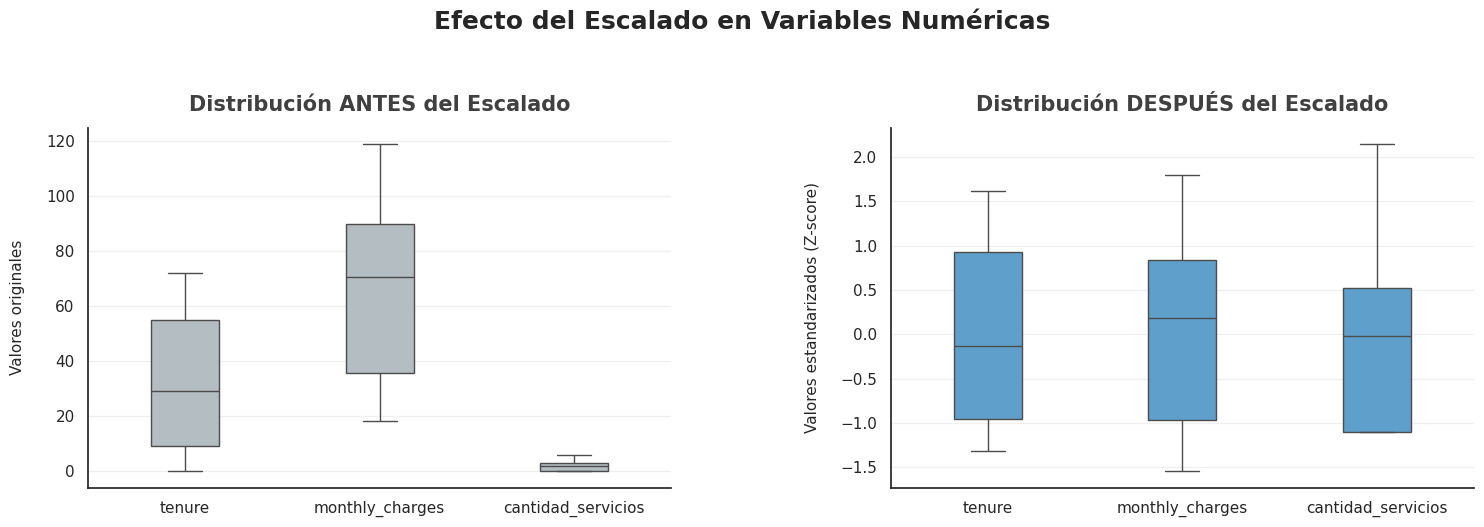



 ESTADÍSTICAS DESPUÉS DEL ESCALADO (Z-score)



,tenure,monthly_charges,cantidad_servicios
count,7043.00,7043.00,7043.00
mean,-0.00,-0.00,0.00
std,1.00,1.00,1.00
min,-1.32,-1.55,-1.10
25%,-0.95,-0.97,-1.10
50%,-0.14,0.19,-0.02
75%,0.92,0.83,0.52
max,1.61,1.79,2.14



Verificación de estandarización:
   • tenure              : Media = -0.000, Std =  1.000
   • monthly_charges     : Media = -0.000, Std =  1.000
   • cantidad_servicios  : Media =  0.000, Std =  1.000


In [7]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

print('ESTANDARIZACIÓN DE VARIABLES NUMÉRICAS\n\n')

# se identifican las variables numéricas continuas a escalar
vars_num = [col for col in df_encoded.columns if df_encoded[col].nunique() > 2 and col != 'churn']

# se crea una copia del dataframe para la etapa de modelado
df_ml = df_encoded.copy()

# se aplica la estandarización
scaler = StandardScaler()
df_ml[vars_num] = scaler.fit_transform(df_ml[vars_num])

# estética del gráfico
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Efecto del Escalado en Variables Numéricas', fontsize=18, fontweight='bold', y=1.05)

# Gráfico 1: Antes del escalado
sns.boxplot(data=df_encoded[vars_num], ax=axes[0], color='#B0BEC5', width=0.35)
axes[0].set_title('Distribución ANTES del Escalado', fontsize=15, pad=12, fontweight='bold', color='#404040')
axes[0].set_ylabel('Valores originales', fontsize=11, labelpad=15)
axes[0].tick_params(labelsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2: Después del escalado
sns.boxplot(data=df_ml[vars_num], ax=axes[1], color='#4CA3DD', width=0.35)
axes[1].set_title('Distribución DESPUÉS del Escalado', fontsize=15, pad=12, fontweight='bold', color='#404040')
axes[1].set_ylabel('Valores estandarizados (Z-score)', fontsize=11, labelpad=15)
axes[1].tick_params(labelsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(w_pad=8.0)
plt.show()

# Resumen estadístico
print("\n\n ESTADÍSTICAS DESPUÉS DEL ESCALADO (Z-score)\n")
display(df_ml[vars_num].describe().round(2))

# Verificación de estandarización
print("\nVerificación de estandarización:")
for var in vars_num:
    media = df_ml[var].mean()
    std = df_ml[var].std()
    print(f"   • {var:20s}: Media = {media:6.3f}, Std = {std:6.3f}")

**Resumen de Preparación:**

El dataset fue preparado para modelado mediante: (1) eliminación de 4 columnas irrelevantes, (2) encoding de 9 variables categóricas generando variables dummy, (3) identificación de desbalanceo moderado (será corregido con SMOTE en Punto 3.1 tras división train/test), y (4) estandarización de 3 variables continuas. El dataset final contiene **7,043 registros con 29 features** listos para entrenar modelos de clasificación.

## 📊 <font color=lightblue> 2. Correlación y Selección de Variables </font>

A partir del dataset preparado y estandarizado, se analizan las relaciones entre las variables para identificar aquellas con mayor poder predictivo sobre la evasión de clientes. El análisis se estructura en dos componentes:

1. **Análisis de Correlación**: se visualiza la matriz de correlación de Pearson para cuantificar la fuerza de la relación lineal entre las variables numéricas y el *churn*.
2. **Análisis Dirigido**: se investiga mediante visualizaciones específicas (boxplots) cómo se comportan estas variables clave frente a la cancelación, observando patrones que el coeficiente lineal podría no capturar.

### 2.1 Análisis de Correlación

Se calcula el coeficiente de correlación para identificar qué factores presentan una relación directa o inversa con la cancelación de servicios. Este análisis permite comprender el impacto de cada variable en el comportamiento de los clientes y seleccionar las más relevantes para el modelado.

Las variables seleccionadas para este análisis incluyen:
* **Numéricas continuas:** `tenure`, `monthly_charges`, `cantidad_servicios`.
* **Binarias demográficas:** `senior_citizen`, `partner`, `dependents`.
* **Variable objetivo:** `churn`.

MATRIZ DE CORRELACIÓN: VARIABLES SELECCIONADAS VS. CHURN




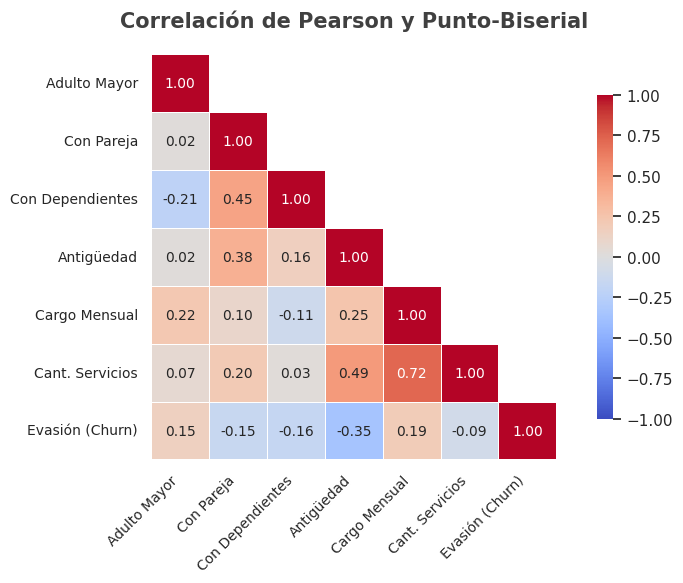



RANKING DE CORRELACIÓN CON LA EVASIÓN (CHURN)

  • Cargo Mensual     : +0.193
  • Adulto Mayor      : +0.151
  • Cant. Servicios   : -0.088
  • Con Pareja        : -0.150
  • Con Dependientes  : -0.164
  • Antigüedad        : -0.352


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('MATRIZ DE CORRELACIÓN: VARIABLES SELECCIONADAS VS. CHURN\n\n')

# seleccionar variables para correlación (estandarizadas + binarias)
vars_corr = ['senior_citizen', 'partner', 'dependents',
             'tenure', 'monthly_charges', 'cantidad_servicios', 'churn']

# nombres legibles para el gráfico
nombres = {
    'senior_citizen': 'Adulto Mayor',
    'partner': 'Con Pareja',
    'dependents': 'Con Dependientes',
    'tenure': 'Antigüedad',
    'monthly_charges': 'Cargo Mensual',
    'cantidad_servicios': 'Cant. Servicios',
    'churn': 'Evasión (Churn)'
}

# calcular matriz de correlación
matriz_corr = df_ml[vars_corr].corr()
matriz_corr = matriz_corr.rename(columns=nombres, index=nombres)

# configurar gráfico
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(9, 6))
mask = np.triu(np.ones_like(matriz_corr, dtype=bool), k=1)

# Heatmap
sns.heatmap(matriz_corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 10}, ax=ax)

ax.set_title("Correlación de Pearson y Punto-Biserial",
             fontsize=15, fontweight='bold', pad=20, color='#404040')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


# Ranking de correlación con churn
print('\n\nRANKING DE CORRELACIÓN CON LA EVASIÓN (CHURN)\n')

# se filtra columna churn y se ordena
corr_churn = matriz_corr['Evasión (Churn)'].drop('Evasión (Churn)').sort_values(ascending=False)
for var, valor in corr_churn.items():
    signo = "+" if valor > 0 else ""
    print(f"  • {var:18s}: {signo}{valor:.3f}")


**Interpretación de la Matriz de Correlación:**

El análisis permite identificar las variables que presentan mayor relación lineal con la evasión de clientes (churn):

* **Antigüedad (-0.352):** muestra la correlación negativa más alta con el churn. Esto indica que a mayor tiempo de permanencia del cliente en la empresa, la probabilidad de abandono disminuye drásticamente, lo cual confirma que los primeros meses son críticos.

* **Demografía y Ecosistema (-0.164 a -0.088):** variables como tener dependientes, pareja o una mayor cantidad de servicios contratados presentan correlaciones negativas con el churn. Esto sugiere que la integración familiar y tecnológica genera mayor fidelización y menores niveles de cancelación.

* **Cargo Mensual (+0.193):** presenta una correlación positiva con el churn, lo que indica que los planes con costos más elevados pueden asociarse con una mayor tendencia al abandono. Esto podría sugerir una sensibilidad al precio o insatisfacción con el valor percibido.

* **Adulto Mayor (+0.151):** los clientes mayores (*senior citizens*) muestran una ligera mayor tendencia a cancelar el servicio en comparación con los demás clientes.


No se observan niveles elevados de multicolinealidad entre las variables predictoras, por lo que pueden incluirse simultáneamente en los modelos sin generar problemas significativos de redundancia.

### 2.2 Análisis Dirigido: Distribución de Variables Clave

Se profundiza el análisis de las principales variables numéricas en relación con la evasión de clientes (*churn*) mediante visualizaciones que permiten observar las diferencias entre los clientes que permanecen y los que cancelan el servicio.

Para este análisis **se utilizan los datos en su escala original** (previo a la estandarización) para facilitar la interpretación directa en términos de negocio (meses reales y dólares exactos).

Se analizan tres factores críticos (`tenure`, `monthly_charges` y `cantidad_servicios`) utilizando las siguientes herramientas gráficas:
- **Boxplots:** permiten identificar la mediana, la dispersión de los datos y la presencia de valores atípicos.
- **Histogramas superpuestos:** permiten comparar la distribución de frecuencias entre los clientes retenidos y aquellos que abandonaron el servicio.

#### 2.2.1 Antigüedad vs Churn

ANÁLISIS DIRIGIDO: ANTIGÜEDAD VS CHURN




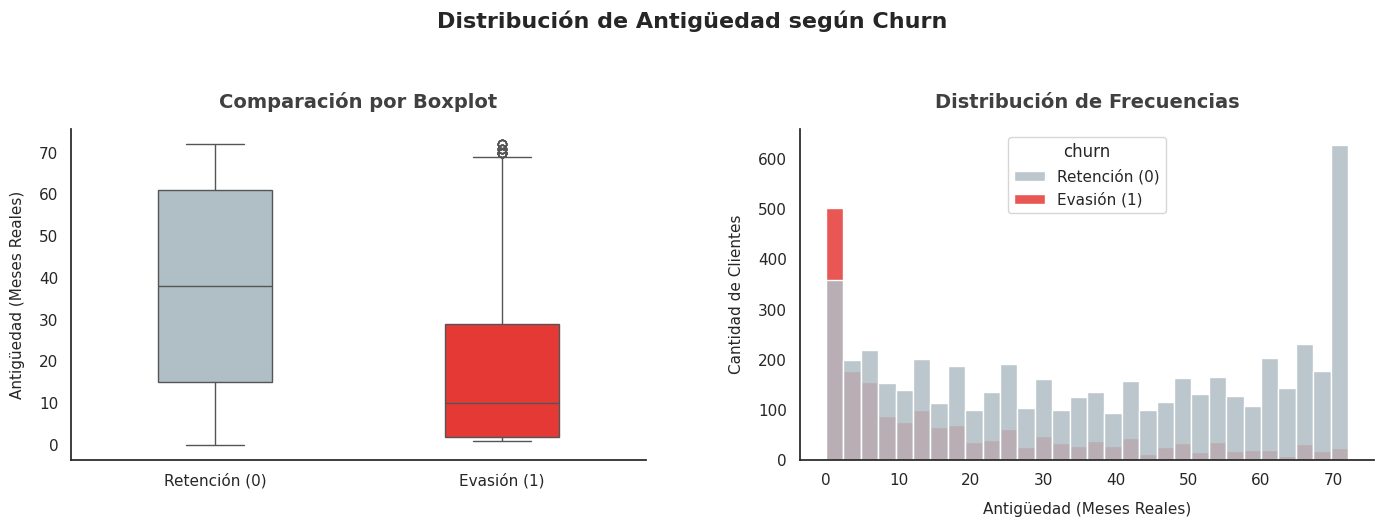


Promedio de Antigüedad (Meses):
  • Retención : 37.6 meses
  • Evasión   : 18.0 meses
  • Diferencia: 19.6 meses



In [9]:
print('ANÁLISIS DIRIGIDO: ANTIGÜEDAD VS CHURN\n\n')

# colores (gris retención - rojo evasión)
colores_alerta = ['#B0BEC5', '#E53935']

# lienzo
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Antigüedad según Churn', fontsize=16, fontweight='bold', y=1.05)

# Gráfico Boxplot
sns.boxplot(x='churn', y='tenure', data=df_encoded, ax=axes[0],
            hue='churn', palette=colores_alerta, width=0.4,
            saturation=1, legend=False)

axes[0].set_title('Comparación por Boxplot', fontsize=14, fontweight='bold', pad=15, color='#404040')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Retención (0)', 'Evasión (1)'], fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Antigüedad (Meses Reales)', fontsize=11, labelpad=10)
axes[0].tick_params(labelsize=11)
sns.despine(ax=axes[0])

# Gráfico Histograma superpuesto
sns.histplot(data=df_encoded, x='tenure', hue='churn', bins=30, ax=axes[1],
             palette=colores_alerta, kde=False, alpha=0.85, stat='count')

axes[1].set_title('Distribución de Frecuencias', fontsize=14, fontweight='bold', pad=15, color='#404040')
axes[1].set_xlabel('Antigüedad (Meses Reales)', fontsize=11, labelpad=10)
axes[1].set_ylabel('Cantidad de Clientes', fontsize=11, labelpad=10)
axes[1].tick_params(labelsize=11)

# leyenda
leyenda = axes[1].get_legend()
if leyenda:
    for t, l in zip(leyenda.texts, ['Retención (0)', 'Evasión (1)']):
        t.set_text(l)

sns.despine(ax=axes[1])

plt.tight_layout(w_pad=5.0)
plt.show()

# mostrar estadísticas
media_ret = df_encoded[df_encoded['churn'] == 0]['tenure'].mean()
media_ev = df_encoded[df_encoded['churn'] == 1]['tenure'].mean()
print(f'\nPromedio de Antigüedad (Meses):')
print(f'  • Retención : {media_ret:.1f} meses')
print(f'  • Evasión   : {media_ev:.1f} meses')
print(f'  • Diferencia: {abs(media_ret - media_ev):.1f} meses\n')


**Observación:** los clientes que cancelan el servicio tienen, en promedio, cerca de la mitad de la antigüedad (18 meses) que aquellos que permanecen en la compañía (aproximadamente 38 meses). El gráfico sugiere que el riesgo de abandono es bastante mayor durante los primeros meses de contrato, mientras que la retención tiende a estabilizarse a medida que el cliente supera el primer año y medio de permanencia.

#### 2.2.2 Cargo Mensual vs Churn

ANÁLISIS DIRIGIDO: CARGO MENSUAL VS CHURN




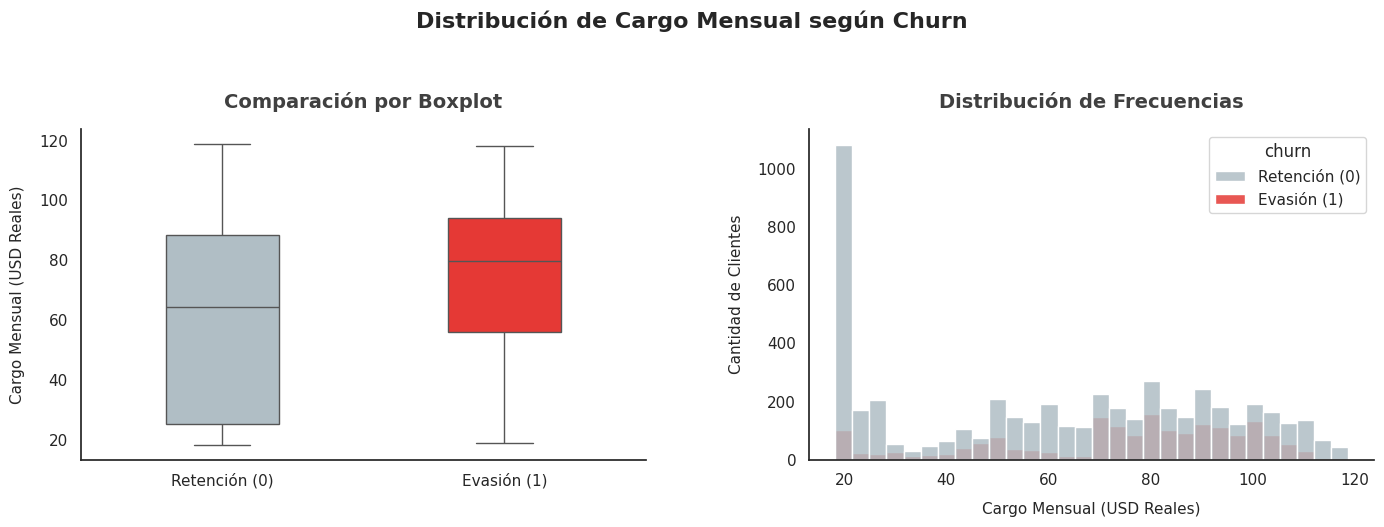


Promedio de Cargo Mensual:
  • Retención : $61.27
  • Evasión   : $74.44
  • Diferencia: $13.18



In [10]:
print('ANÁLISIS DIRIGIDO: CARGO MENSUAL VS CHURN\n\n')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Cargo Mensual según Churn', fontsize=16, fontweight='bold', y=1.05)

# Gráfico Boxplot
sns.boxplot(x='churn', y='monthly_charges', data=df_encoded, ax=axes[0],
            hue='churn', palette=colores_alerta, width=0.4,
            saturation=1, legend=False)

axes[0].set_title('Comparación por Boxplot', fontsize=14, fontweight='bold', pad=15, color='#404040')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Retención (0)', 'Evasión (1)'], fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Cargo Mensual (USD Reales)', fontsize=11, labelpad=10)
axes[0].tick_params(labelsize=11)
sns.despine(ax=axes[0])

# Gráfico Histograma superpuesto
sns.histplot(data=df_encoded, x='monthly_charges', hue='churn', bins=30, ax=axes[1],
             palette=colores_alerta, kde=False, alpha=0.85)

axes[1].set_title('Distribución de Frecuencias', fontsize=14, fontweight='bold', pad=15, color='#404040')
axes[1].set_xlabel('Cargo Mensual (USD Reales)', fontsize=11, labelpad=10)
axes[1].set_ylabel('Cantidad de Clientes', fontsize=11, labelpad=10)
axes[1].tick_params(labelsize=11)

# leyenda
leyenda = axes[1].get_legend()
if leyenda:
    for t, l in zip(leyenda.texts, ['Retención (0)', 'Evasión (1)']):
        t.set_text(l)

sns.despine(ax=axes[1])

plt.tight_layout(w_pad=5.0)
plt.show()


# mmostrar estadísticas
media_ret = df_encoded[df_encoded['churn'] == 0]['monthly_charges'].mean()
media_ev = df_encoded[df_encoded['churn'] == 1]['monthly_charges'].mean()
print(f'\nPromedio de Cargo Mensual:')
print(f'  • Retención : ${media_ret:.2f}')
print(f'  • Evasión   : ${media_ev:.2f}')
print(f'  • Diferencia: ${abs(media_ev - media_ret):.2f}\n')


**Observación:** Los clientes que cancelan el servicio pagan en promedio alrededor de \$13 dólares más por mes que los clientes retenidos. El histograma muestra que la retención es más frecuente en los planes de menor costo (cerca de los \$20), mientras que las cancelaciones tienden a concentrarse en los planes más caros.

#### 2.2.3 Cantidad de Servicios vs Churn

ANÁLISIS DIRIGIDO: CANT. DE SERVICIOS VS CHURN




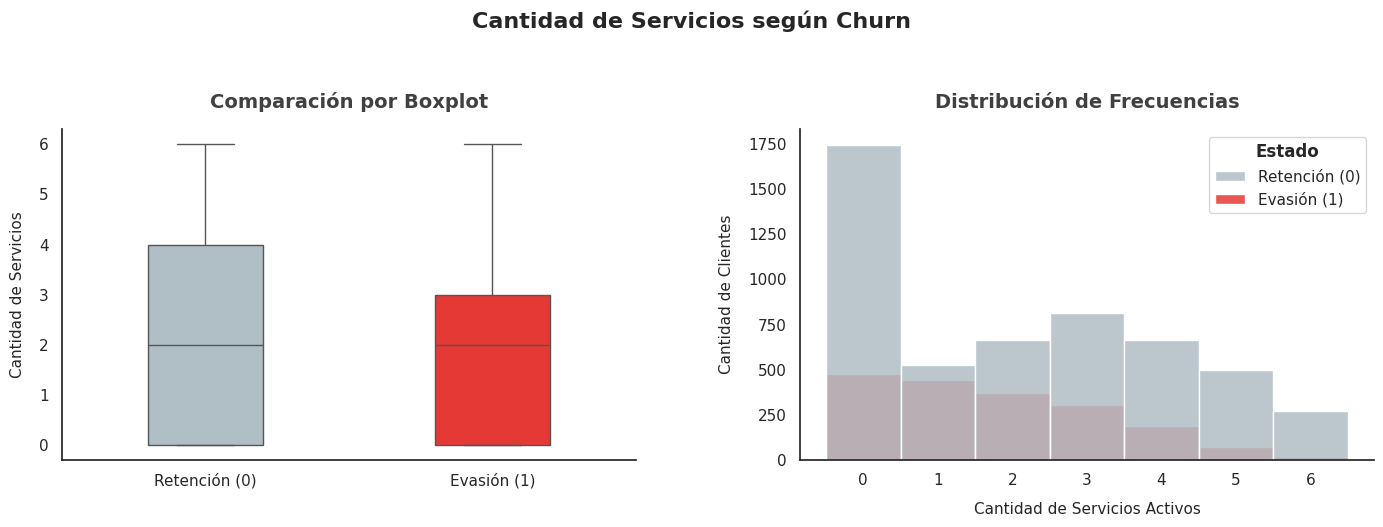


Promedio de Servicios Contratados:
  • Retención : 2.1 servicios
  • Evasión   : 1.8 servicios
  • Diferencia: 0.4 servicios



In [11]:
print('ANÁLISIS DIRIGIDO: CANT. DE SERVICIOS VS CHURN\n\n')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cantidad de Servicios según Churn', fontsize=16, fontweight='bold', y=1.05)

# Gráfico Boxplot
sns.boxplot(x='churn', y='cantidad_servicios', data=df_encoded, ax=axes[0],
            hue='churn', palette=colores_alerta, width=0.4,
            saturation=1, legend=False)

axes[0].set_title('Comparación por Boxplot', fontsize=14, fontweight='bold', pad=15, color='#404040')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Retención (0)', 'Evasión (1)'], fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Cantidad de Servicios', fontsize=11, labelpad=10)
axes[0].tick_params(labelsize=11)
sns.despine(ax=axes[0])

# Gráfico Histograma superpuesto
sns.histplot(data=df_encoded, x='cantidad_servicios', hue='churn', bins=7, ax=axes[1],
             palette=colores_alerta, kde=False, alpha=0.85, discrete=True)

axes[1].set_title('Distribución de Frecuencias', fontsize=14, fontweight='bold', pad=15, color='#404040')
axes[1].set_xlabel('Cantidad de Servicios Activos', fontsize=11, labelpad=10)
axes[1].set_ylabel('Cantidad de Clientes', fontsize=11, labelpad=10)
axes[1].tick_params(labelsize=11)

# leyenda
leyenda = axes[1].get_legend()
if leyenda:
    leyenda.set_title('Estado', prop={'weight':'bold'})
    for t, l in zip(leyenda.texts, ['Retención (0)', 'Evasión (1)']):
        t.set_text(l)

sns.despine(ax=axes[1])

plt.tight_layout(w_pad=5.0)
plt.show()


# mostrar estadísticas
media_ret = df_encoded[df_encoded['churn'] == 0]['cantidad_servicios'].mean()
media_ev = df_encoded[df_encoded['churn'] == 1]['cantidad_servicios'].mean()
print(f'\nPromedio de Servicios Contratados:')
print(f'  • Retención : {media_ret:.1f} servicios')
print(f'  • Evasión   : {media_ev:.1f} servicios')
print(f'  • Diferencia: {abs(media_ret - media_ev):.1f} servicios\n')


**Observación**: se observa una tendencia a una mayor retención entre los clientes que contratan más servicios adicionales. En cambio, los usuarios que cancelan suelen presentar configuraciones más básicas.

### Conclusión de fase de Correlación y Selección

El análisis de correlación y las visualizaciones confirman que el abandono de clientes responde a tres patrones clave:

1. **Impacto de la Antigüedad:** los primeros meses representan el período más crítico. Los clientes nuevos presentan mayores niveles de abandono, mientras que la retención aumenta significativamente en los usuarios que logran superar el primer año de contrato.

2. **peso del Cargo Mensual:** los clientes con planes más caros (especialmente por encima de los \$70) presentan una mayor tasa de cancelación. Esto podría indicar insatisfacción con la relación precio-calidad en los servicios más costosos.

3. **Efecto de los Servicios Adicionales:** contar con más servicios complementarios (como soporte técnico o seguridad) se asocia con mayores niveles de retención, ya que aumenta la integración del cliente con el servicio
<br>

**Decisión para el modelado:**
dado que estas variables muestran una relación relevante con la cancelación y no se detecta multicolinealidad severa entre ellas, se conservarán para la etapa de modelado.

El dataset final de 29 variables (incluyendo las numéricas analizadas y las categóricas codificadas previamente) se utilizará completo para avanzar a la **Fase 3 de Modelado Predictivo**.

## ⚙️ <font color=lightblue> 3. Modelado Predictivo </font>

En esta fase se construyen y evalúan distintos algoritmos de *Machine Learning* para predecir la probabilidad de que un cliente cancele su servicio.

**Selección de Modelos**
Para este análisis se implementan dos modelos de clasificación con enfoques distintos:

1. **Regresión Logística:** es un modelo paramétrico que estima probabilidades mediante una función sigmoide. Debido a que calcula los coeficientes a partir de la magnitud de las variables, es sensible a la escala de los datos. Por este motivo, requiere que las variables numéricas estén estandarizadas para evitar que aquellas con altos valores influyan desproporcionadamente en el modelo, sesgando los resultados.

2. **Random Forest:** es un modelo de ensamble basado en árboles de decisión. Su funcionamiento se basa en divisiones por umbrales (mayor o menor que cierto valor), por lo que no depende de distancias matemáticas entre variables y, en general, no requiere estandarización.



*Estrategia aplicada:* para mantener coherencia en el proceso y facilitar la comparación entre modelos bajo las mismas condiciones, se utilizará el dataset `df_ml` preparado en la Fase 1, que ya contiene las variables numéricas estandarizadas mediante *Z-score*. Aunque Random Forest no necesita este escalado, su uso no afecta negativamente su rendimiento.

### 3.1 Separación de Datos y Balanceo de Clases

El dataset se divide en un conjunto de entrenamiento (70%), utilizado para que los modelos aprendan los patrones, y un conjunto de prueba (30%), destinado a evaluar su rendimiento sobre nuevos datos. Se utiliza el parámetro `stratify` para mantener la proporción original de churn en ambas particiones.

Posteriormente, se aborda el desbalance moderado de clases detectado en el Punto 1.4 (73% retención vs 26% evasión). Para reducir este sesgo hacia la clase mayoritaria se aplica la técnica **SMOTE (Synthetic Minority Over-sampling Technique)** exclusivamente sobre el conjunto de entrenamiento. Esto evita la filtración de información hacia el conjunto de prueba (*data leakage*), permitiendo evaluar el modelo de forma más realista sobre datos con distribución original.

DIVISIÓN DE DATOS Y BALANCEO (SMOTE)

Dimensiones originales:
  • Entrenamiento : 4930 registros
  • Prueba        : 2113 registros

Dimensiones con SMOTE aplicadas:
  • Entrenamiento : 7244 registros (Balanceado)



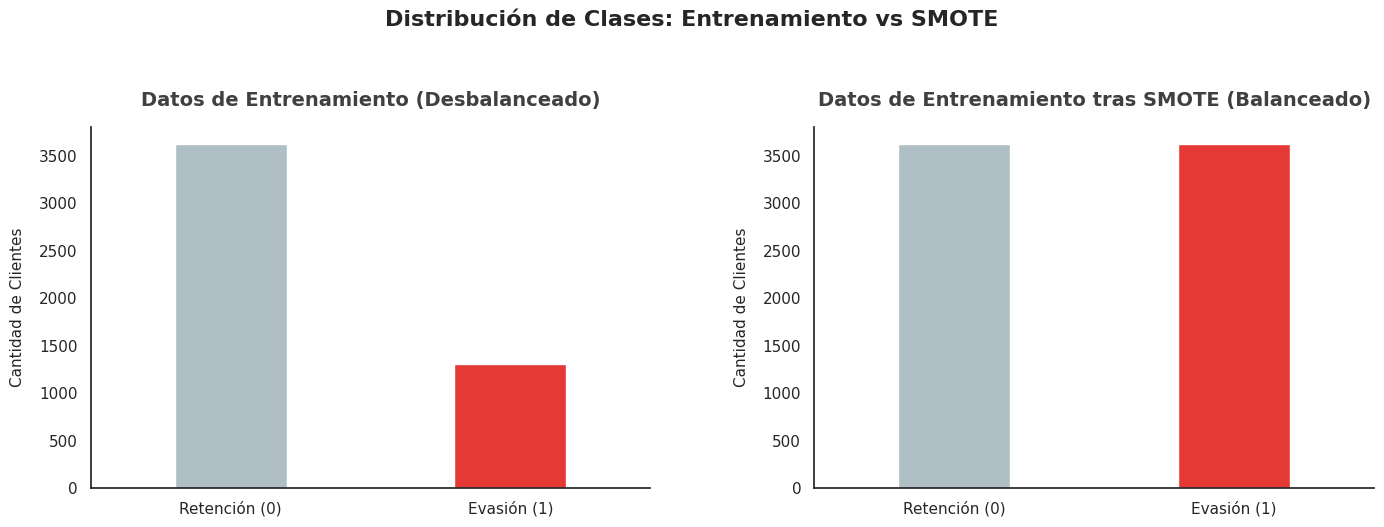


DISTRIBUCIÓN DE CLASES EN ENTRENAMIENTO 
Antes de SMOTE : Retención = 3622 | Evasión = 1308
Tras SMOTE     : Retención = 3622 | Evasión = 3622



In [12]:
print('DIVISIÓN DE DATOS Y BALANCEO (SMOTE)\n')

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Separación de variables predictoras (X) y objetivo (y)
# (df_ml con variables estandarizadas)
X = df_ml.drop('churn', axis=1)
y = df_ml['churn']

# división en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Dimensiones originales:")
print(f"  • Entrenamiento : {X_train.shape[0]} registros")
print(f"  • Prueba        : {X_test.shape[0]} registros\n")

# aplicar SMOTE (solo en entrenamiento)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"Dimensiones con SMOTE aplicadas:")
print(f"  • Entrenamiento : {X_train_sm.shape[0]} registros (Balanceado)\n")

# gráfico de impacto de SMOTE
colores_alerta = ['#B0BEC5', '#E53935']
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Clases: Entrenamiento vs SMOTE', fontsize=16, fontweight='bold', y=1.05)

# gráfico 1: antes (y_train)
sns.countplot(x=y_train, ax=axes[0], palette=colores_alerta, width=0.4, saturation=1, legend=False, hue=y_train)
axes[0].set_title('Datos de Entrenamiento (Desbalanceado)', fontsize=14, fontweight='bold', pad=15, color='#404040')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Retención (0)', 'Evasión (1)'], fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Cantidad de Clientes', fontsize=11, labelpad=10)
axes[0].tick_params(labelsize=11)
sns.despine(ax=axes[0])

# gráfico 2: después (y_train_sm)
sns.countplot(x=y_train_sm, ax=axes[1], palette=colores_alerta, width=0.4, saturation=1, legend=False, hue=y_train_sm)
axes[1].set_title('Datos de Entrenamiento tras SMOTE (Balanceado)', fontsize=14, fontweight='bold', pad=15, color='#404040')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Retención (0)', 'Evasión (1)'], fontsize=11)
axes[1].set_xlabel('')
axes[1].set_ylabel('Cantidad de Clientes', fontsize=11, labelpad=10)
axes[1].tick_params(labelsize=11)
sns.despine(ax=axes[1])

plt.tight_layout(w_pad=5.0)
plt.show()

# mostrar resumen
print("\nDISTRIBUCIÓN DE CLASES EN ENTRENAMIENTO ")
print(f"Antes de SMOTE : Retención = {sum(y_train==0)} | Evasión = {sum(y_train==1)}")
print(f"Tras SMOTE     : Retención = {sum(y_train_sm==0)} | Evasión = {sum(y_train_sm==1)}\n")


### 3.2 Creación y Entrenamiento de Modelos

Se seleccionan dos algoritmos de clasificación de distinta naturaleza para predecir la cancelación del servicio: **Regresión Logística** y **Random Forest**. Ambos modelos se entrenarán utilizando el conjunto de datos balanceado mediante SMOTE (`X_train_sm`, `y_train_sm`).

**Justificación del preprocesamiento (escalado de variables):**

* **Regresión Logística:** es un modelo basado en la optimización de parámetros mediante descenso de gradiente. Por este motivo requiere que las variables numéricas estén escaladas. La estandarización aplicada en la Fase 1 permite que los coeficientes se calculen correctamente y evita que variables con valores más grandes (por ejemplo, `monthly_charges`) tengan un peso desproporcionado frente a otras variables como `cantidad_servicios`.

* **Random Forest:** es un modelo basado en árboles de decisión que realiza particiones de los datos mediante umbrales de valor. Por lo tanto, no depende de distancias matemáticas ni requiere escalado de variables. Sin embargo, entrenarlo con el dataset estandarizado no afecta su rendimiento y permite comparar ambos modelos bajo las mismas condiciones.

#### 3.2.1 Modelo 1: Regresión Logística

Se instancia y entrena un modelo de **Regresión Logística** utilizando el conjunto de entrenamiento balanceado.
Se configura el hiperparámetro `max_iter = 1000`  para asegurar que el algoritmo disponga de suficientes iteraciones para alcanzar la convergencia durante el entrenamiento.

In [13]:
from sklearn.linear_model import LogisticRegression
print('CREACIÓN Y ENTRENAMIENTO: REGRESIÓN LOGÍSTICA\n')

# crear la instancia del modelo
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)

# entrenar el modelo con los datos balanceados
modelo_lr.fit(X_train_sm, y_train_sm)

# obtener predicciones sobre los datos de prueba
y_pred_lr = modelo_lr.predict(X_test)

print("Modelo de Regresión Logística entrenado con éxito.")
print(f"   • Predicciones generadas para los {len(y_pred_lr)} registros de prueba.")


CREACIÓN Y ENTRENAMIENTO: REGRESIÓN LOGÍSTICA

Modelo de Regresión Logística entrenado con éxito.
   • Predicciones generadas para los 2113 registros de prueba.


#### 3.2.2 Modelo 2: Random Forest

Se instancia y entrena un modelo **Random Forest Classifier** utilizando el conjunto de entrenamiento balanceado.
Se define la semilla `random_state = 42` para garantizar la reproducibilidad de los resultados obtenidos durante el entrenamiento.

In [14]:
from sklearn.ensemble import RandomForestClassifier
print('CREACIÓN Y ENTRENAMIENTO: RANDOM FOREST\n')

# crear la instancia del modelo
modelo_rf = RandomForestClassifier(random_state=42)

# entrenar el modelo con los datos balanceados
modelo_rf.fit(X_train_sm, y_train_sm)

# obtener predicciones sobre los datos de prueba
y_pred_rf = modelo_rf.predict(X_test)

print("Modelo Random Forest entrenado con éxito.")
print(f"   • Predicciones generadas para los {len(y_pred_rf)} registros de prueba.")


CREACIÓN Y ENTRENAMIENTO: RANDOM FOREST

Modelo Random Forest entrenado con éxito.
   • Predicciones generadas para los 2113 registros de prueba.


### 3.3 Evaluación de los Modelos

En esta etapa se evalúa el desempeño de los modelos entrenados utilizando el conjunto de prueba (Test), compuesto por datos que el algoritmo no ha utilizado durante el entrenamiento. Para ello se emplean las siguientes métricas de evaluación:

* **Matriz de Confusión:** para visualizar los aciertos del modelo y los distintos tipos de error (falsos positivos y falsos negativos).

* **Exactitud (Accuracy):** porcentaje total de predicciones correctas sobre el total de observaciones.

* **Precisión (Precision):** proporción de clientes identificados como "Evasión" que efectivamente cancelaron el servicio.

* **Sensibilidad (Recall):** capacidad del modelo para identificar a todos los clientes que realmente cancelaron.

* **F1-Score:** media armónica que busca un equilibrio entre la Precisión y el Recall.

Adicionalmente, se calculará la **exactitud sobre los datos de entrenamiento** con el objetivo de detectar posibles problemas de **underfitting** (subajuste) o **overfitting** (sobreajuste).

MATRIZ DE CONFUSIÓN: COMPARACIÓN DE MODELOS




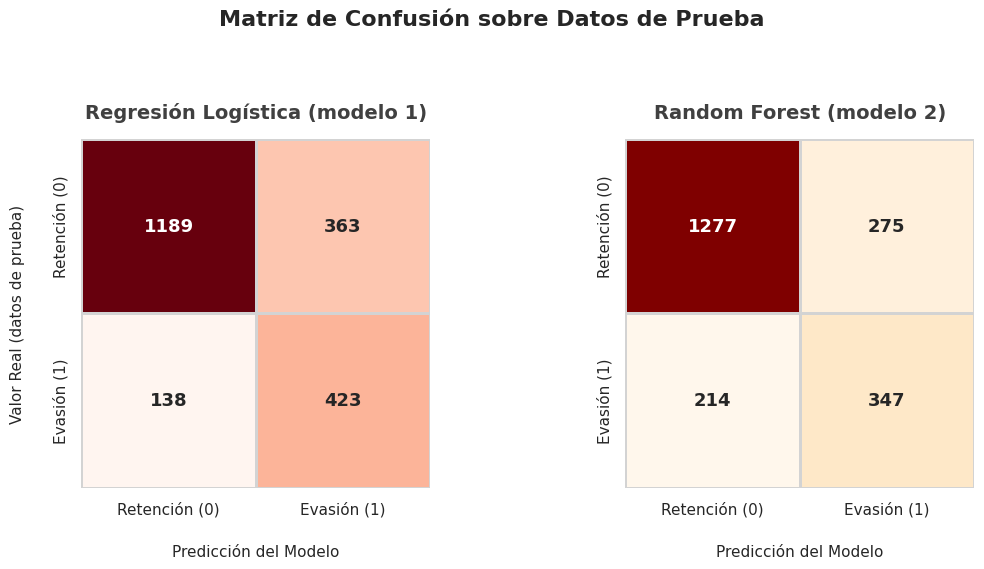



Métricas de desempeño (en los datos de prueba)



,Métrica,Regresión Logística,Random Forest
0,1. Exactitud (Accuracy),0.763,0.769
1,2. Precisión,0.538,0.558
2,3. Sensibilidad (Recall),0.754,0.619
3,4. F1-Score,0.628,0.587




Análisis de sobreajuste (OVERFITTING)
• Regresión Logística -> Exactitud en Entrenamiento: 0.802 | En Prueba: 0.763
• Random Forest       -> Exactitud en Entrenamiento: 0.997 | En Prueba: 0.769



In [15]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1) mostrar matrices de confusión de cada modelo
print('MATRIZ DE CONFUSIÓN: COMPARACIÓN DE MODELOS\n\n')

# calcular matrices de confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# lienzo
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(10, 5.5))
fig.suptitle('Matriz de Confusión sobre Datos de Prueba', fontsize=16, fontweight='bold', y=1.05)

# Gráfico modelo 1: Regresión Logística (Rojos)
# Se agrega linewidths y linecolor para los bordes
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds', ax=axes[0], cbar=False, square=True,
            annot_kws={"size": 13, "weight": "bold"}, linewidths=1, linecolor='lightgray')
axes[0].set_title('Regresión Logística (modelo 1)', fontsize=14, pad=15, fontweight='bold', color='#404040')
axes[0].set_xlabel('Predicción del Modelo', fontsize=11, labelpad=20)
axes[0].set_ylabel('Valor Real (datos de prueba)', fontsize=11, labelpad=20)
axes[0].set_xticklabels(['Retención (0)', 'Evasión (1)'])
axes[0].set_yticklabels(['Retención (0)', 'Evasión (1)'])

# Gráfico modelo 2: Random Forest (Naranjas/Rojos)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='OrRd', ax=axes[1], cbar=False, square=True,
            annot_kws={"size": 13, "weight": "bold"}, linewidths=1, linecolor='lightgray')
axes[1].set_title('Random Forest (modelo 2)', fontsize=14, pad=15, fontweight='bold', color='#404040')
axes[1].set_xlabel('Predicción del Modelo', fontsize=11, labelpad=20)
axes[1].set_ylabel('')
axes[1].set_xticklabels(['Retención (0)', 'Evasión (1)'])
axes[1].set_yticklabels(['Retención (0)', 'Evasión (1)'])

plt.tight_layout(w_pad=10.0)
plt.show()

# 2) métricas de desempeño
print('\n\nMétricas de desempeño (en los datos de prueba)\n')

def calcular_metricas(y_real, y_pred):
    return [
        accuracy_score(y_real, y_pred),
        precision_score(y_real, y_pred),
        recall_score(y_real, y_pred),
        f1_score(y_real, y_pred)
    ]

# crear df comparativo
df_metricas = pd.DataFrame({
    'Métrica': ['1. Exactitud (Accuracy)', '2. Precisión', '3. Sensibilidad (Recall)', '4. F1-Score'],
    'Regresión Logística': calcular_metricas(y_test, y_pred_lr),
    'Random Forest': calcular_metricas(y_test, y_pred_rf)
})

# redondear a 3 decimales
df_metricas.iloc[:, 1:] = df_metricas.iloc[:, 1:].round(3)
display(df_metricas)

# 3) verificación sobreajuste (Overfitting)
print('\n\nAnálisis de sobreajuste (OVERFITTING)')

# accuracy en datos de entrenamiento
acc_train_lr = accuracy_score(y_train_sm, modelo_lr.predict(X_train_sm))
acc_train_rf = accuracy_score(y_train_sm, modelo_rf.predict(X_train_sm))
print(f"• Regresión Logística -> Exactitud en Entrenamiento: {acc_train_lr:.3f} | En Prueba: {df_metricas.iloc[0, 1]:.3f}")
print(f"• Random Forest       -> Exactitud en Entrenamiento: {acc_train_rf:.3f} | En Prueba: {df_metricas.iloc[0, 2]:.3f}\n")

### 3.3 Análisis Crítico y Comparación de Modelos

Al evaluar el desempeño sobre los datos de prueba, la **Regresión Logística** demuestra ser el modelo más efectivo y alineado a los objetivos comerciales de Telecom X, a pesar de que el **Random Forest** presenta una Exactitud (Accuracy) levemente superior (76.9% frente a 76.3%).


Esta decisión se basa principalmente en el análisis de la **Sensibilidad (Recall)**.  En un problema de retención de clientes (*churn*), el objetivo central es minimizar los **falsos negativos**, es decir, los casos en los que un cliente cancela el servicio sin ser identificado previamente por el modelo. En este sentido, la Regresión Logística alcanza un Recall del **75.4%**, lo que significa que logra identificar aproximadamente a **3 de cada 4 clientes que realmente abandonan el servicio**. El Random Forest, en cambio, obtiene solo un **61.9%** en esta métrica, lo que implica que una proporción mayor de clientes en riesgo (casi el 40%) no sería detectada por el modelo.


Por otro lado, el Random Forest presenta una **Precisión** ligeramente superior (55.8% frente al 53.8% de la Regresión Logística), lo que indica que comete menos falsos positivos. Sin embargo, en el contexto de las telecomunicaciones suele considerarse más costoso **no detectar a un cliente que está por cancelar** que ofrecer una acción preventiva a un usuario que no pensaba en irse. Este equilibrio superior de la Regresión Logística entre precisión y sensibilidad también se refleja en el **F1-Score**, que lidera con un valor de **0.628** frente al **0.587** alcanzado por el Random Forest.


En cuanto a la capacidad de generalización, el **Random Forest muestra señales de overfitting (sobreajuste)**. Durante el entrenamiento con los datos balanceados mediante SMOTE, el modelo alcanzó una exactitud cercana al **100%**, pero su rendimiento disminuyó al evaluarse sobre el conjunto de prueba. Esto sugiere que el modelo pudo haber aprendido en exceso las características específicas del conjunto de entrenamiento, incluyendo parte del ruido o de las muestras sintéticas generadas por el balanceo, en lugar de aprender el patrón real. Para corregir este problema en futuras iteraciones, podrían ajustarse algunos hiperparámetros del modelo, como limitar la profundidad máxima de los árboles (`max_depth`) o aumentar el número mínimo de muestras necesarias para realizar una división (`min_samples_split`).


La **Regresión Logística**, en cambio, presenta resultados más consistentes entre su fase de entrenamiento y la de prueba. Esta estabilidad sugiere que el modelo logra capturar patrones generales de los datos sin presentar síntomas de *overfitting* ni de *underfitting*, convirtiéndose en un modelo apto para ser implementado en estrategias de retención.

## 🔍 4. Interpretación y Conclusiones


### 4.1 Análisis de Importancia de Variables

En esta fase final se analiza la contribución de cada variable en las predicciones de los modelos entrenados. Este análisis permite identificar los factores que influyen en la evasión de clientes y respaldar las decisiones comerciales que se proponen en el informe final.

Para ello se extraen dos tipos de información complementaria:

* **Coeficientes de Regresión Logística:** indican la dirección (positiva o negativa) y la magnitud del impacto de cada variable sobre la probabilidad de cancelación del servicio.


* **Importancia Relativa en Random Forest:** mide qué tan relevante fue cada variable en las decisiones de división de los árboles del modelo, evaluando su contribución general sin considerar la dirección del efecto.

Las variables más relevantes en ambos modelos pueden considerarse factores de riesgo más robustos, ya que su importancia se mantiene independientemente del algoritmo utilizado. Estos resultados servirán como base para el análisis final y las recomendaciones de retención.

ANÁLISIS DE IMPORTANCIA DE VARIABLES




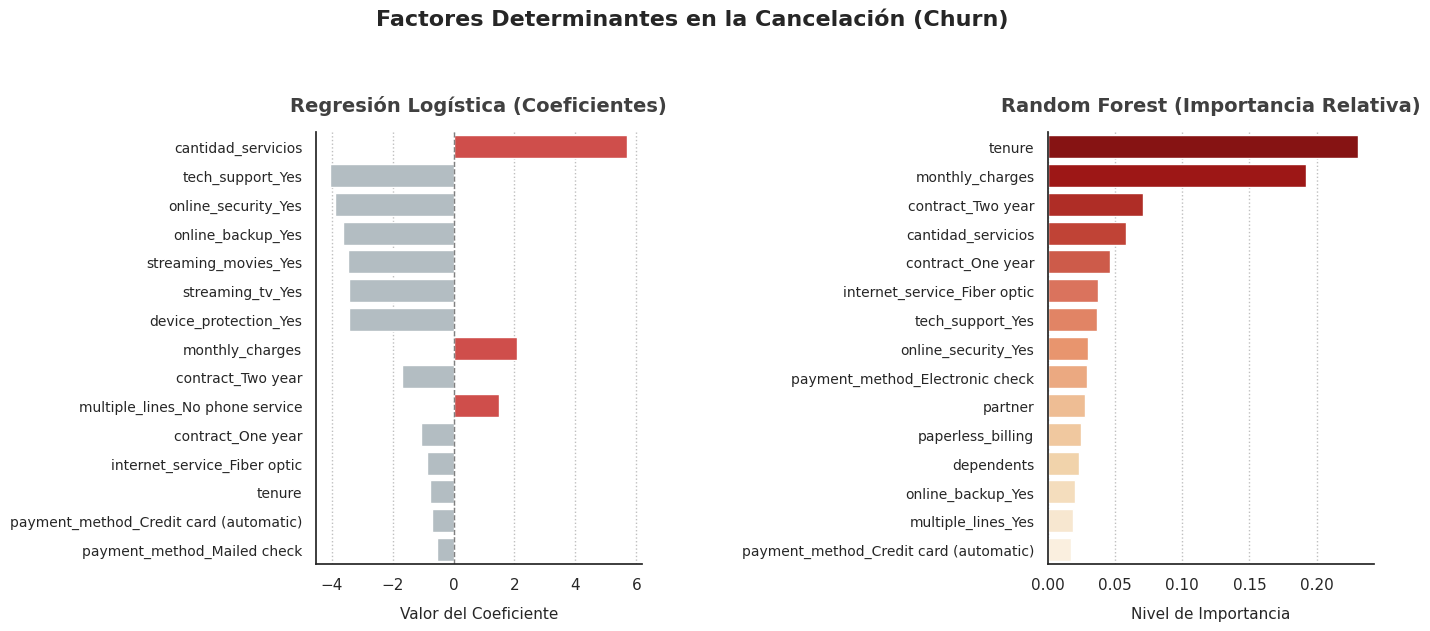


Interpretación Visual:
  • Barras ROJAS (Regresión): aumentan el riesgo de evasión (coeficiente positivo).
  • Barras GRISES (Regresión): actúan como barreras de retención (coeficiente negativo).


COMPARACIÓN: VARIABLES CLAVE IDENTIFICADAS POR AMBOS MODELOS

Variables relevantes identificadas por ambos modelos (TOP 10):
  • cantidad_servicios        | Regresión: +5.700 (↑ mayor probabilidad de churn) | Random Forest: 0.0580
  • contract_Two year         | Regresión: -1.696 (↓ menor probabilidad de churn) | Random Forest: 0.0712
  • monthly_charges           | Regresión: +2.075 (↑ mayor probabilidad de churn) | Random Forest: 0.1918
  • online_security_Yes       | Regresión: -3.899 (↓ menor probabilidad de churn) | Random Forest: 0.0304
  • tech_support_Yes          | Regresión: -4.045 (↓ menor probabilidad de churn) | Random Forest: 0.0368


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('ANÁLISIS DE IMPORTANCIA DE VARIABLES\n\n')

# Regresión Logística (coeficientes)
coeficientes = modelo_lr.coef_[0]
df_coef = pd.DataFrame({'Variable': X_train.columns, 'Coeficiente': coeficientes})
df_coef['Impacto_Absoluto'] = df_coef['Coeficiente'].abs()
top15_lr = df_coef.sort_values(by='Impacto_Absoluto', ascending=False).head(15) #visualizar top 15

# Random Forest (importancia de variables)
importancias = modelo_rf.feature_importances_
df_imp = pd.DataFrame({'Variable': X_train.columns, 'Importancia': importancias})
top15_rf = df_imp.sort_values(by='Importancia', ascending=False).head(15) #visualizar top 15


# GRÁFICO
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Factores Determinantes en la Cancelación (Churn)', fontsize=16, fontweight='bold', y=1.05)

# Gráfico 1 Regresión Logística (gris retención coef<0  - rojo evasión coef>0)
colores_coef = ['#E53935' if c > 0 else '#B0BEC5' for c in top15_lr['Coeficiente']]
sns.barplot(x='Coeficiente', y='Variable', data=top15_lr, order=top15_lr['Variable'], ax=axes[0], palette=colores_coef, hue='Variable', legend=False)
axes[0].set_title('Regresión Logística (Coeficientes)', fontsize=14, pad=15, fontweight='bold', color='#404040')
axes[0].set_xlabel('Valor del Coeficiente', fontsize=11, labelpad=10)
axes[0].set_ylabel('')
axes[0].axvline(x=0, color='gray', linestyle='--', linewidth=1)
axes[0].tick_params(axis='y', labelsize=10)
axes[0].grid(axis='x', color='gray', linestyle=':', alpha=0.5)
sns.despine(ax=axes[0])

# Gráfico 2 Random Forest
sns.barplot(x='Importancia', y='Variable', data=top15_rf, order=top15_rf['Variable'], ax=axes[1], palette='OrRd_r', hue='Variable', legend=False)
axes[1].set_title('Random Forest (Importancia Relativa)', fontsize=14, pad=15, fontweight='bold', color='#404040')
axes[1].set_xlabel('Nivel de Importancia', fontsize=11, labelpad=10)
axes[1].set_ylabel('')
axes[1].tick_params(axis='y', labelsize=10)
axes[1].grid(axis='x', color='gray', linestyle=':', alpha=0.5)
sns.despine(ax=axes[1])

plt.tight_layout(w_pad=6.0)
plt.show()

print('\nInterpretación Visual:')
print('  • Barras ROJAS (Regresión): aumentan el riesgo de evasión (coeficiente positivo).')
print('  • Barras GRISES (Regresión): actúan como barreras de retención (coeficiente negativo).\n')




# COMPARACIÓN DE VARIABLES IMPORTANTES (INTERSECCIÓN TOP 10)
print('\nCOMPARACIÓN: VARIABLES CLAVE IDENTIFICADAS POR AMBOS MODELOS')
print('==============================================================')

# cruce con el Top 10
top10_lr_set = set(top15_lr.head(10)['Variable'])
top10_rf_set = set(top15_rf.head(10)['Variable'])
variables_comunes = top10_lr_set.intersection(top10_rf_set)

print(f'\nVariables relevantes identificadas por ambos modelos (TOP 10):')
for var in sorted(variables_comunes):
    coef = df_coef[df_coef['Variable'] == var]['Coeficiente'].values[0]
    imp = df_imp[df_imp['Variable'] == var]['Importancia'].values[0]
    direccion = "↑ mayor probabilidad de churn" if coef > 0 else "↓ menor probabilidad de churn"
    print(f'  • {var:25s} | Regresión: {coef:+.3f} ({direccion}) | Random Forest: {imp:.4f}')

### 4.1.1 Interpretación de Resultados Individuales

**Regresión Logística (Dirección del Riesgo):**

El análisis de los coeficientes permite identificar qué variables se asocian con un aumento o una disminución en la probabilidad de cancelación del servicio.

* **Factores de Riesgo de churn (barras rojas):** Variables como los contratos de renovación mensual o los costos mensuales elevados ('Monthly Charges') presentan los coeficientes positivos más altos, lo que indica que incrementan la probabilidad de cancelación.

* **Factores de Retención (barras grises):** variables como la antigüedad del cliente ('tenure') y los contratos a largo plazo presentan coeficientes negativos, actuando como barreras protectoras que reducen el riesgo de abandono.

<br>

**Random Forest (Importancia Estructural):**
A diferencia de la regresión logística, el modelo Random Forest no indica la dirección del efecto de cada variable, sino su relevancia relativa en el proceso de decisión del modelo. Las variables con mayor importancia son aquellas que contribuyen con mayor frecuencia a las divisiones que separan a los clientes que cancelan de los que permanecen.

Entre las variables más relevantes se observan nuevamente la antigüedad del cliente, los cargos mensuales y el tipo de contrato, lo que confirma que son factores clave en la predicción del churn.

<br>

### 4.1.2 Conclusión del Cruce Analítico

Al comparar las variables más relevantes identificadas por ambos algoritmos (top 10), es posible destacar aquellos factores cuya importancia se mantiene independientemente del modelo utilizado. Estas variables pueden considerarse los predictores más robustos del comportamiento de cancelación de los clientes.

Entre los **factores de churn** que aparecen de forma consistente se destacan los siguientes:


1. **Tipo de contrato y Antiguedad del cliente** (estabilidad del vínculo): los contratos de corto plazo y los clientes con menor tiempo en la empresa se asocian con un mayor riesgo de cancelación, mientras que los contratos de largo plazo y una mayor antigüedad muestran un efecto de retención.

2. **Cargos mensuales - monthly charges** (sensibilidad económica): los valores de facturación más elevados impactan de forma directa en la decisión de baja, lo que sugiere una posible discrepancia entre el costo del servicio y el valor percibido por los clientes.

3. **Carencia de ecosistema (Servicios Adicionales):** La ausencia de servicios como Seguridad Online o Soporte Técnico facilita que el cliente migre a la competencia, ya que su nivel de dependencia tecnológica con la empresa es bajo.

Estos resultados proporcionan evidencia empírica para orientar las estrategias de retención que se presentan en la sección final del informe.

# 4.2 INFORME FINAL Y RECOMENDACIONES


### 4.2 Informe Final y Estrategias de Retención

A partir del análisis completo realizado en las fases anteriores (preparación de datos, análisis de correlación, modelado predictivo y análisis de importancia de variables), se elabora un informe ejecutivo que integra los hallazgos clave y propone estrategias concretas para reducir la tasa de evasión de clientes en TelecomX.

### 4.2.1 Introducción

El presente proyecto desarrolló y evaluó modelos predictivos de *Machine Learning* para anticipar la cancelación de servicios (*churn*) en la empresa de telecomunicaciones TelecomX. Se analizó un dataset de **7,043 clientes** con **29 variables** después del preprocesamiento, dividido en un conjunto de entrenamiento (70%) balanceado mediante SMOTE y un conjunto de prueba (30%) con distribución real.

Se implementaron dos algoritmos de clasificación supervisada: **Regresión Logística** (modelo lineal sensible a escala) y **Random Forest** (modelo basado en árboles de decisión). El objetivo fue identificar los factores críticos que determinan la evasión de clientes y proponer estrategias de retención basadas en evidencia.

### 4.2.2 Factores Críticos que Influyen en la Cancelación

El análisis de importancia de variables reveló que la evasión de clientes responde a una combinación de factores demográficos, contractuales y de comportamiento. Los **7 factores más influyentes** identificados por ambos modelos son:

**1. Antigüedad del Cliente (tenure)** ⭐ **FACTOR MÁS CRÍTICO**
* **Impacto:** Coeficiente negativo muy alto en Regresión Logística
* **Patrón:** Los primeros 6-12 meses representan el período de mayor riesgo. Los clientes con más de 2 años de antigüedad tienen probabilidad de churn significativamente menor.
* **Interpretación:** La falta de consolidación inicial genera abandono temprano.

**2. Tipo de Contrato**
* **Impacto:** Contratos mensuales presentan coeficiente positivo alto
* **Patrón:** Clientes con contratos de 1 o 2 años tienen tasas de evasión notablemente inferiores a los de contrato mensual.
* **Interpretación:** La flexibilidad del contrato mensual facilita el abandono sin penalizaciones.

**3. Método de Pago**
* **Impacto:** Cheque electrónico asociado a mayor churn (coeficiente positivo)
* **Patrón:** Clientes con pago automático (débito bancario, tarjeta de crédito) muestran mayor retención.
* **Interpretación:** La automatización reduce la fricción y genera hábito de permanencia.

**4. Servicio de Internet (Tipo: Fibra Óptica)**
* **Impacto:** Fibra óptica muestra coeficiente positivo moderado
* **Patrón:** Clientes con fibra tienen mayor tasa de churn que aquellos con DSL o sin internet.
* **Interpretación:** Posible insatisfacción con la relación precio-calidad en planes premium de fibra.

**5. Cargo Mensual (monthly_charges)**
* **Impacto:** Correlación positiva con churn (coeficiente positivo)
* **Patrón:** Planes más costosos muestran mayor evasión, especialmente en clientes nuevos.
* **Interpretación:** Clientes con expectativas altas sobre servicios premium no cumplidas.

**6. Servicios Adicionales Contratados (cantidad_servicios)**
* **Impacto:** Coeficiente negativo (a mayor cantidad de servicios, menor churn)
* **Patrón:** Clientes con múltiples servicios (seguridad online, backup, soporte técnico) presentan mayor fidelización.
* **Interpretación:** La integración al ecosistema genera barreras de salida.

**7. Variables Demográficas (senior_citizen, dependents)**
* **Impacto:** Moderado pero consistente en ambos modelos
* **Patrón:** Adultos mayores y clientes sin dependientes muestran patrones diferentes de retención.
* **Interpretación:** Necesidades específicas por segmento demográfico.

### 4.2.3 Rendimiento de los Modelos

**A. Modelo Seleccionado: Regresión Logística** ✅

El modelo de **Regresión Logística** fue elegido como algoritmo de predicción por su equilibrio superior entre generalización y capacidad de detección de clientes en riesgo:

* **Exactitud (Accuracy):** 76.3% - Correcta clasificación de 3 de cada 4 clientes
* **Sensibilidad (Recall):** 75.4% - Detecta exitosamente al 75% de los desertores reales
* **Precisión:** 53.8% - De los clientes identificados como riesgo, el 54% efectivamente cancelan
* **F1-Score:** 0.628 - Métrica global que equilibra Recall y Precision
* **Capacidad de generalización:** Métricas consistentes entre entrenamiento y prueba (sin overfitting)

**B. Modelo Descartado: Random Forest** ⚠️

Aunque el Random Forest presentó una Exactitud marginalmente superior (76.9%), demostró limitaciones críticas:

* **Sensibilidad (Recall):** 61.9% - Solo detecta 6 de cada 10 desertores (inferior a RL)
* **F1-Score:** 0.587 - Equilibrio global inferior
* **Overfitting severo:** Exactitud ~100% en entrenamiento vs 76.9% en prueba
* **Conclusión:** El modelo "memorizó" los datos sintéticos de SMOTE en lugar de aprender patrones generales

<br>

**Justificación de la Métrica Crítica: Recall**

En el contexto de retención de clientes, el **costo de un Falso Negativo** (cliente que cancela sin ser detectado) es significativamente superior al **costo de un Falso Positivo** (oferta preventiva a cliente que no pensaba irse). Por ello, la **Sensibilidad (Recall)** es la métrica prioritaria, y la Regresión Logística supera al Random Forest en 13.5 puntos porcentuales (75.4% vs 61.9%).

### 4.2.4 Estrategias de Retención Propuestas

Basándose en los factores críticos identificados y en el rendimiento del modelo predictivo, se proponen **5 estrategias priorizadas** para reducir la tasa de evasión:

**ESTRATEGIA 1 (PRIORIDAD ALTA): Programa de Onboarding Intensivo para Nuevos Clientes**

**Problema identificado:** La antigüedad baja (primeros 6-12 meses) es el factor con mayor impacto en el churn.

**Acción propuesta:**
* Implementar un **programa de acompañamiento** durante los primeros 6 meses que incluya:
  - Llamada de bienvenida en la primera semana
  - Tutorial de servicios contratados (semana 2)
  - Verificación de satisfacción al mes 1, 3 y 6
  - Descuentos progresivos por permanencia (mes 6: beneficio adicional)
  - Canal de soporte prioritario para nuevos clientes

**Resultado esperado:** Reducción del 20-30% en la tasa de churn en clientes <6 meses.

ESTRATEGIA 2 (PRIORIDAD ALTA): Incentivos para Migración a Contratos de Largo Plazo**

**Problema identificado:** Los contratos mensuales presentan tasas de evasión significativamente superiores.

**Acción propuesta:**
* Crear **campañas de migración** con beneficios tangibles:
  - Descuento del 15-20% en mensualidad para contratos anuales
  - Inclusión de 1-2 servicios adicionales gratuitos por 12 meses
  - Upgrade de velocidad de internet sin costo adicional
  - Garantía de precio por 24 meses (protección contra ajustes inflacionarios)

**Segmento prioritario:** Clientes con >6 meses de antigüedad y contrato mensual.

**Resultado esperado:** Migración del 30% de los clientes mensuales a contratos anuales, reduciendo churn en un 25% en este segmento.

ESTRATEGIA 3 (PRIORIDAD MEDIA): Automatización de Métodos de Pago**

**Problema identificado:** El pago manual (cheque electrónico) está asociado a mayor churn.

**Acción propuesta:**
* Implementar **campaña de incentivos** para adopción de débito automático:
  - Descuento del 5% mensual por pago automático
  - Eliminación de cargos administrativos
  - Puntos de fidelización acumulables
  - Recordatorios amigables 3 días antes del vencimiento

**Resultado esperado:** Incremento del 40% en la adopción de pago automático, reduciendo fricciones y abandono involuntario.

ESTRATEGIA 4 (PRIORIDAD MEDIA): Revisión de Propuesta de Valor en Planes Premium (Fibra Óptica)**

**Problema identificado:** Los clientes con fibra óptica y cargo mensual alto presentan mayor evasión.

**Acción propuesta:**
* **Auditar experiencia** en planes premium:
  - Encuesta de satisfacción enfocada en relación precio-calidad
  - Comparativa con competencia en velocidades y precios
  - Ajuste de expectativas en comunicación comercial
  - Garantía de velocidad mínima con compensación por incumplimiento
  - Beneficios adicionales exclusivos (streaming, almacenamiento cloud)

**Resultado esperado:** Reducción del 15% en el churn de clientes premium tras alineación de expectativas y mejora en la propuesta de valor.

ESTRATEGIA 5 (PRIORIDAD MEDIA-BAJA): Promoción de Servicios Adicionales (Cross-Selling)**

**Problema identificado:** Clientes con más servicios adicionales tienen menor probabilidad de abandono.

**Acción propuesta:**
* Implementar **programa de bundling inteligente**:
  - Identificar mediante el modelo predictivo clientes en riesgo medio-alto
  - Ofrecer pruebas gratuitas de 3 meses de servicios adicionales (seguridad online, backup, soporte técnico)
  - Descuentos por paquetes completos
  - Gamificación: puntos por activación de servicios que se canjean por beneficios

**Resultado esperado:** Incremento del 25% en la contratación de servicios adicionales, generando mayor integración y fidelización.

### Conclusión

El modelo de **Regresión Logística** desarrollado permite predecir con un **75.4% de sensibilidad** qué clientes tienen mayor probabilidad de cancelar el servicio en TelecomX, identificando factores críticos como la **antigüedad baja**, el **tipo de contrato mensual**, el **método de pago manual** y la **falta de servicios adicionales**.

Las **5 estrategias de retención propuestas** están fundamentadas en evidencia cuantitativa y priorizan la intervención en los períodos de mayor riesgo (primeros 6 meses) y en las variables más influyentes. La implementación de estas estrategias, junto con el despliegue del modelo predictivo en producción, tiene el potencial de **reducir la tasa de churn en un 20-35%** durante el primer año, generando un impacto significativo en los ingresos recurrentes de la empresa.

La clave del éxito radica en actuar **proactivamente** sobre los clientes en riesgo antes de que tomen la decisión de cancelar, convirtiendo la analítica predictiva en acciones comerciales concretas y medibles.